In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import torch.nn as nn
import torch
from tqdm.autonotebook import tqdm
import seaborn as sns
from Environments.igt import IGTEnv
from BasalGanglia.train import train
import pickle

C:\Users\chari\AppData\Local\Temp\ipykernel_6700\2546923693.py:6: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


<!-- ## Hyperparameters -->


In [2]:
TRAILS = 100
EPOCHS = 150
NUM_BINS = 5
LR = 0.1
NUM_ARMS = 4
SCALING_FACTOR = 100
REW_STD = 0
LOSS_STD = 0

<!-- ## Simulation -->

In [3]:
env = IGTEnv(mean_reward=np.array([100,100,50,50])/SCALING_FACTOR,
             std_reward=np.array([REW_STD,REW_STD,REW_STD,REW_STD])/SCALING_FACTOR,
             mean_loss=np.array([-250,-1250,-50,-250])/SCALING_FACTOR,
             std_loss=np.array([LOSS_STD,LOSS_STD,LOSS_STD,LOSS_STD])/SCALING_FACTOR)

In [4]:
reward_monitor, arm_chosen_monitor, avg_counts,ip_monitor, dp_monitor,ep_monitor= train(env, 
                                                      trails = TRAILS, 
                                                      epochs = EPOCHS, 
                                                      lr = LR, 
                                                      bins = NUM_BINS,
                                                      STN_data = None, 
                                                      d1_amp=0.5,
                                                      d2_amp=0.01, 
                                                      gpi_threshold=0.15,
                                                      max_gpi_iters=50,
                                                      del_lim=1.2, train_IP = True, 
                                                      del_med = None, printing = False,
                                                      gpi_mean= 1, ep_0 = 0.07,
                                                      alpha_ep = 0.0,
                                                      eta_ep = 0.0,
                                                      baseline_ep = 0.0, 
                                                      ep_lim = None, k_lim = None)


Using Random noise


<!-- ## Analysis -->

In [5]:
A_picks = avg_counts[0]
B_picks = avg_counts[1]
C_picks = avg_counts[2]
D_picks = avg_counts[3]

Avg_A_picks = torch.mean(A_picks, dim = 0)
Avg_B_picks = torch.mean(B_picks, dim = 0)
Avg_C_picks = torch.mean(C_picks, dim = 0)
Avg_D_picks = torch.mean(D_picks, dim = 0)

IGT_score = torch.mean(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim = 0).squeeze().numpy()
IGT_dev = torch.std(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim = 0)/torch.sqrt(torch.tensor(EPOCHS, dtype = torch.float32))
IGT_dev = IGT_dev.squeeze().numpy()

print(f'IGT score: {IGT_score} with SE of {IGT_dev}')

IGT score: [-12.28        -3.8133333   -0.01333333  -2.8933334   -7.04      ] with SE of [0.98780566 1.462228   1.3944596  1.4064773  1.403826  ]


In [6]:
A_picks = avg_counts[0]
B_picks = avg_counts[1]
C_picks = avg_counts[2]
D_picks = avg_counts[3]

Avg_A_picks = torch.mean(A_picks, dim = 0)
Avg_B_picks = torch.mean(B_picks, dim = 0)
Avg_C_picks = torch.mean(C_picks, dim = 0)
Avg_D_picks = torch.mean(D_picks, dim = 0)

IP_A = torch.mean(ip_monitor[0], dim = 0).detach().numpy()
IP_B = torch.mean(ip_monitor[1], dim = 0).detach().numpy()
IP_C = torch.mean(ip_monitor[2], dim = 0).detach().numpy()
IP_D = torch.mean(ip_monitor[3], dim = 0).detach().numpy()

DP_A = torch.mean(dp_monitor[0], dim = 0).detach().numpy()
DP_B = torch.mean(dp_monitor[1], dim = 0).detach().numpy()
DP_C = torch.mean(dp_monitor[2], dim = 0).detach().numpy()
DP_D = torch.mean(dp_monitor[3], dim = 0).detach().numpy()

IGT_score = torch.mean(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim = 0)
IGT_dev = torch.std(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim = 0)/torch.sqrt(torch.tensor(EPOCHS, dtype = torch.float32))

IP_all = np.array([IP_A[:,0],IP_B[:,0],IP_C[:,0],IP_D[:,0]])
IP_Var = np.std(IP_all,axis = 0 )

<!-- ## Results -->

Text(0.5, 0, 'trails')

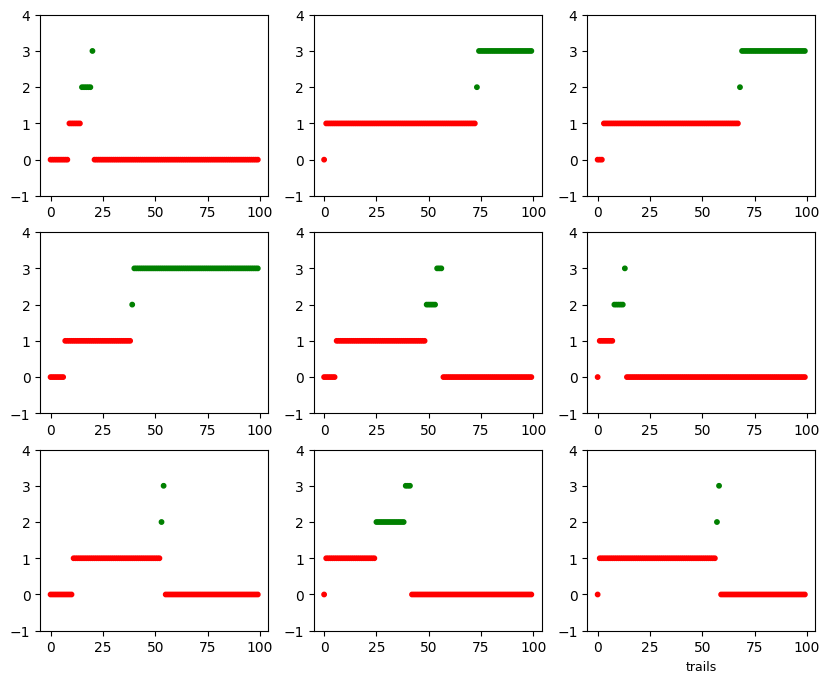

In [7]:
random_pick = np.random.choice(np.arange(EPOCHS), size = 9)

plt.figure(figsize=(10,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    colors = np.where(np.isin(arm_chosen_monitor[random_pick[i]],[0,1]), 'r', 'g')
    plt.scatter(np.arange(TRAILS), arm_chosen_monitor[random_pick[i]], c = colors, s = 10)
    plt.ylim(-1,4)
plt.xlabel('trails', fontsize = 9)


tensor([[-12.2800],
        [ -3.8133],
        [ -0.0133],
        [ -2.8933],
        [ -7.0400]]) tensor([[0.9878],
        [1.4622],
        [1.3945],
        [1.4065],
        [1.4038]])


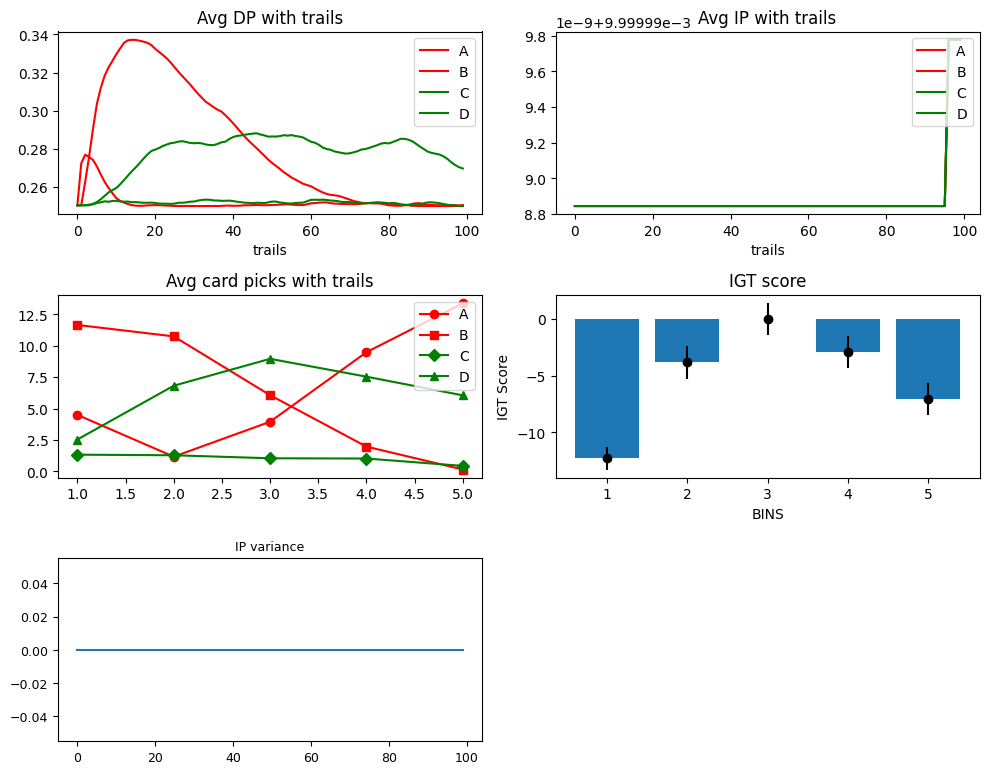

In [8]:
BINS = np.arange(5) + 1

plt.figure(figsize=(10,8))

plt.subplot(321)
plt.plot(np.arange(100), DP_A, label = 'A', color = 'red')
plt.plot(np.arange(100), DP_B, label = 'B', color = 'red')
plt.plot(np.arange(100), DP_C, label = 'C', color = 'green')
plt.plot(np.arange(100), DP_D, label = 'D', color = 'green')
plt.xlabel('trails')
plt.title('Avg DP with trails')
plt.legend(loc = 'upper right')

plt.subplot(322)
plt.plot(np.arange(100), IP_A, label = 'A', color = 'red')
plt.plot(np.arange(100), IP_B, label = 'B', color = 'red')
plt.plot(np.arange(100), IP_C, label = 'C', color = 'green')
plt.plot(np.arange(100), IP_D, label = 'D', color = 'green')
plt.xlabel('trails')
plt.title('Avg IP with trails')
plt.legend(loc = 'upper right')

plt.subplot(323)
plt.plot(BINS,Avg_A_picks, label = 'A', color = 'red', marker = 'o')
plt.plot(BINS,Avg_B_picks, label = 'B', color = 'red', marker = 's')
plt.plot(BINS,Avg_C_picks, label = 'C', color = 'green', marker = 'D')
plt.plot(BINS,Avg_D_picks, label = 'D', color = 'green', marker = '^')
plt.title('Avg card picks with trails')
plt.legend(loc = 'upper right')

plt.subplot(324)
plt.bar(BINS, IGT_score.reshape(5))
print(IGT_score, IGT_dev)
plt.errorbar(BINS, IGT_score.reshape(5), yerr= IGT_dev.reshape(5), fmt='o', color = 'black')
plt.title(f'IGT score')
plt.xlabel('BINS')
plt.ylabel('IGT Score')

plt.subplot(325)
plt.plot(IP_Var)
# plt.ylim(0.0,0.0025)
plt.title('IP variance', fontsize = 9)
plt.xticks(fontsize = 9)
plt.yticks(fontsize = 9)
plt.tight_layout()


In [9]:
# # saving as pickle file

# with open('data_normal_igt.pkl', 'wb') as f:
#     pickle.dump(data_normal, f)

<!-- # Statistical testing -->

IGT score: [-12.28        -3.8133333   -0.01333333  -2.8933334   -7.04      ]


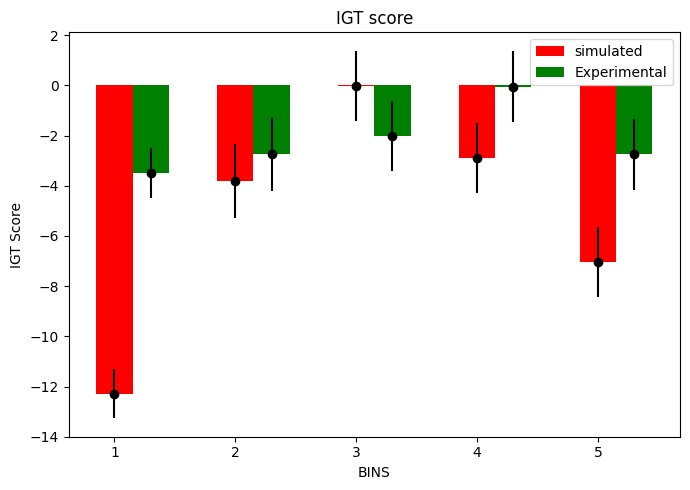

In [10]:
IGT_Simulated = IGT_score.squeeze().detach().numpy()
IGT_expt = np.array([-3.5, -2.75, -2.0, -0.05, -2.75]) #np.array([0.,0.6,1.0,1.5,-1.2 ])#np.array([-3.5, -2.5, -2.0, -0.05, -2.5])
# Plotting bar for IGT
plt.figure(figsize=(7,5))
plt.bar(BINS, IGT_Simulated, width=0.3, color = 'red', label = 'simulated')
plt.errorbar(BINS, IGT_Simulated, yerr= IGT_dev.reshape(5), fmt='o', color = 'black')
plt.bar(BINS+0.3, IGT_expt, width=0.3, color = 'green', label = 'Experimental')
plt.errorbar(BINS+0.3, IGT_expt, yerr=IGT_dev.reshape(5), fmt='o', color = 'black')
# plt.ylim(-5,5)
plt.title(f'IGT score')
plt.xlabel('BINS')
plt.ylabel('IGT Score')
plt.legend()
plt.tight_layout()
print('IGT score:', IGT_Simulated)

In [ ]:
mean_sim = IGT_score.squeeze().detach().numpy()
mean_expt = IGT_expt
std_sim = torch.std(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim = 0).squeeze().detach().numpy()
std_expt = std_sim
n_sim = 100
n_expt = 20

In [ ]:
import math
from scipy.stats import t
import pandas as pd

def compare_multiple_pairs(mean_exp, std_exp, n_exp, mean_sim, std_sim, n_sim):
    results = []

    for i in range(len(mean_exp)):
        m1, s1 = mean_exp[i], std_exp[i]
        m2, s2 = mean_sim[i], std_sim[i]

        # Standard error
        se = math.sqrt((s1**2)/n_exp + (s2**2)/n_sim)

        # t-statistic
        t_stat = (m1 - m2) / se

        # Degrees of freedom (Welch-Satterthwaite)
        df_num = (s1**2/n_exp + s2**2/n_sim)**2
        df_den = ((s1**2/n_exp)**2 / (n_exp - 1)) + ((s2**2/n_sim)**2 / (n_sim - 1))
        df = df_num / df_den

        # Two-tailed p-value
        p_val = 2 * (1 - t.cdf(abs(t_stat), df))
        conclusion = "Statistically different" if p_val < 0.05 else "Not statistically different"

        results.append({
            "Index": i+1,
            "Exp Mean": m1,
            "Sim Mean": m2,
            "t-stat": round(t_stat, 3),
            "p-value": round(p_val, 4),
            "Significant": p_val < 0.05,
            "Conclusion": conclusion

        })

    return pd.DataFrame(results)

# Run comparison
df_results_IGT_mean = compare_multiple_pairs(mean_expt, std_expt, n_expt, mean_sim, std_sim, n_sim)

# Show results
# import ace_tools as tools; tools.display_dataframe_to_user(name="Significance Comparison Results", dataframe=df_results)


In [ ]:
df_results_IGT_mean

,Index,Exp Mean,Sim Mean,t-stat,p-value,Significant,Conclusion
0,1,-3.50,-13.986667,3.909,0.0006,True,Statistically different
1,2,-2.75,-7.080000,1.103,0.2797,False,Not statistically different
2,3,-2.00,-0.680000,-0.313,0.7568,False,Not statistically different
3,4,-0.05,-0.640000,0.136,0.8930,False,Not statistically different
4,5,-2.75,-5.360000,0.604,0.5510,False,Not statistically different


In [ ]:
# data_pd = {'IGT_sim': mean_sim,
#                'IGT_sim_std': std_sim,
#                'IGT_exp': mean_expt,
#                'IGT_exp_std': std_expt,
#                'n_expt': n_expt,
#                'n_sim': n_sim,
#                'article': 'Gescheidt',
#                'condition': 'PD',
#                'statistical test': df_results_IGT_mean}

# with open('data_pd_igt.pkl', 'wb') as f:
#     pickle.dump(data_pd, f)